#  **Face Recognition System**
**Skills:** Python · Computer Vision · Deep Learning · OpenCV · face_recognition

### Features
- Detect faces in uploaded images with bounding boxes & confidence
- Real-time webcam face detection (local deployment)
- Face count, coordinates, and annotated output images
- Professional visualisations

## **Imports**

In [5]:
import cv2
import face_recognition
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
from google.colab import files
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

print(' All libraries imported!')


 All libraries imported!


## **Detection Functions**

In [8]:
def load_image(image_path):
    """Load image in both PIL and face_recognition format."""
    pil_img = Image.open(image_path).convert('RGB')
    fr_img  = face_recognition.load_image_file(image_path)
    cv_img  = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    return pil_img, fr_img, cv_img

def detect_faces(fr_image):
    """Detect all face locations in an image."""
    locations = face_recognition.face_locations(fr_image, model='hog')
    encodings = face_recognition.face_encodings(fr_image, locations)
    return locations, encodings

def annotate_image(pil_image, face_locations, title="Face Detection Result"):
    """Draw bounding boxes and labels on detected faces."""
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(pil_image)

    colors = plt.cm.Set1(np.linspace(0, 1, max(len(face_locations), 1)))

    for i, (top, right, bottom, left) in enumerate(face_locations):
        width  = right - left
        height = bottom - top
        rect   = patches.Rectangle(
            (left, top), width, height,
            linewidth=3, edgecolor=colors[i], facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(left, top - 10,
                f'Face {i+1}',
                color='white', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[i], alpha=0.8))

    ax.set_title(f'{title}\nDetected {len(face_locations)} face(s)',
                 fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('annotated_output.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n{len(face_locations)} face(s) detected')

print('Detection functions ready!')


Detection functions ready!


## **Image Upload & Detection**

Please upload an image (jpg, jpeg, or png):


Saving 145.jpg to 145.jpg

🔍 Analysing: 145.jpg
----------------------------------------
Image Size   : 480 x 471 pixels
Image Mode   : RGB

Detecting faces...
Faces Found  : 2

Face Coordinates (top, right, bottom, left):
  Face 1: top=201, right=221, bottom=387, left=35 | Size: 186x186px
  Face 2: top=180, right=448, bottom=366, left=262 | Size: 186x186px


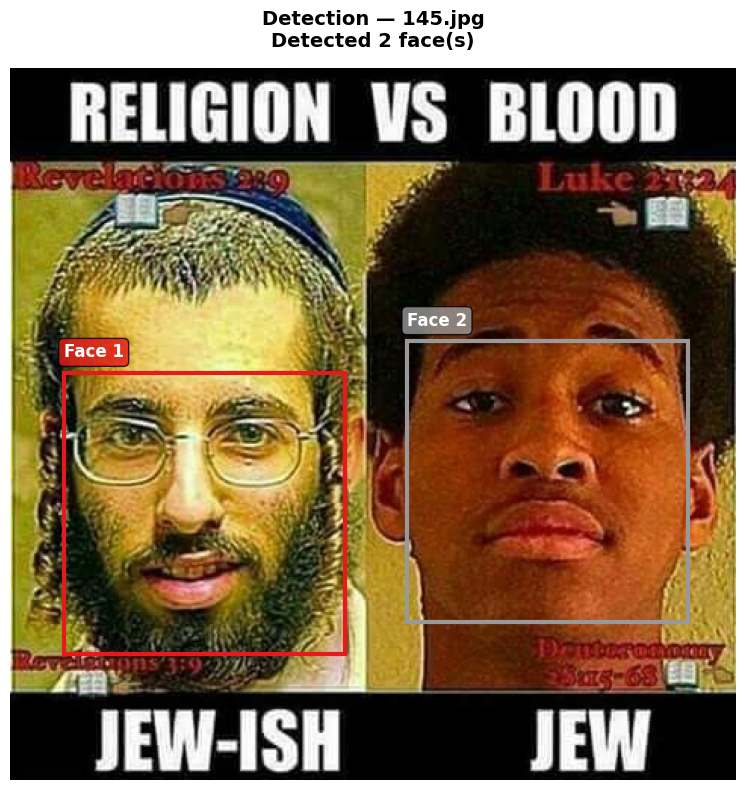


2 face(s) detected


In [9]:
print('Please upload an image (jpg, jpeg, or png):')
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'\n🔍 Analysing: {filename}')
    print('-' * 40)

    pil_img, fr_img, cv_img = load_image(filename)

    # Image info
    width, height = pil_img.size
    print(f'Image Size   : {width} x {height} pixels')
    print(f'Image Mode   : {pil_img.mode}')

    # Detect faces
    print('\nDetecting faces...')
    face_locations, face_encodings = detect_faces(fr_img)

    print(f'Faces Found  : {len(face_locations)}')

    if face_locations:
        print('\nFace Coordinates (top, right, bottom, left):')
        for i, (top, right, bottom, left) in enumerate(face_locations):
            w = right - left
            h = bottom - top
            print(f'  Face {i+1}: top={top}, right={right}, bottom={bottom}, left={left} | Size: {w}x{h}px')

    # Annotate and display
    annotate_image(pil_img, face_locations, title=f"Detection — {filename}")

## **Face Analysis**

Detailed Analysis — 2 face(s) found
Face 1: 186×186 pixels | Position: (35, 201)
Face 2: 186×186 pixels | Position: (262, 180)


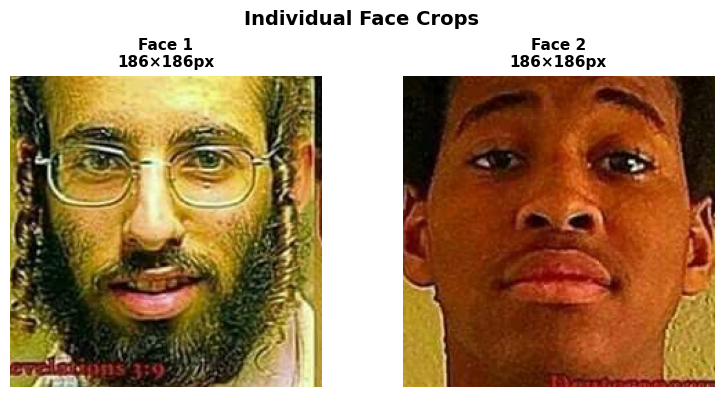

In [10]:
def analyse_faces(image_path):
    """Detailed analysis of all faces in an image."""
    pil_img, fr_img, cv_img = load_image(image_path)
    face_locations, face_encodings = detect_faces(fr_img)

    if not face_locations:
        print('No faces detected in this image.')
        return

    print(f'Detailed Analysis — {len(face_locations)} face(s) found')
    print('=' * 50)

    # Crop and display each face
    n_faces = len(face_locations)
    cols    = min(n_faces, 4)
    rows    = (n_faces + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if n_faces == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = [ax for row in axes for ax in row]

    img_array = np.array(pil_img)

    for i, (top, right, bottom, left) in enumerate(face_locations):
        # Add padding around face
        pad    = 20
        top_p  = max(0, top - pad)
        left_p = max(0, left - pad)
        bot_p  = min(img_array.shape[0], bottom + pad)
        right_p= min(img_array.shape[1], right + pad)

        face_crop = img_array[top_p:bot_p, left_p:right_p]
        w = right - left
        h = bottom - top

        axes[i].imshow(face_crop)
        axes[i].set_title(f'Face {i+1}\n{w}×{h}px', fontweight='bold', fontsize=11)
        axes[i].axis('off')

        print(f'Face {i+1}: {w}×{h} pixels | Position: ({left}, {top})')

    # Hide unused axes
    for j in range(n_faces, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Individual Face Crops', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('face_crops.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run on the last uploaded image
if uploaded:
    last_file = list(uploaded.keys())[-1]
    analyse_faces(last_file)


## **Face Comparison**

Upload TWO images to compare faces:


Saving 189.jpg to 189.jpg
Saving 190.jpg to 190.jpg
Image 1: 2 face(s) | Image 2: 1 face(s)


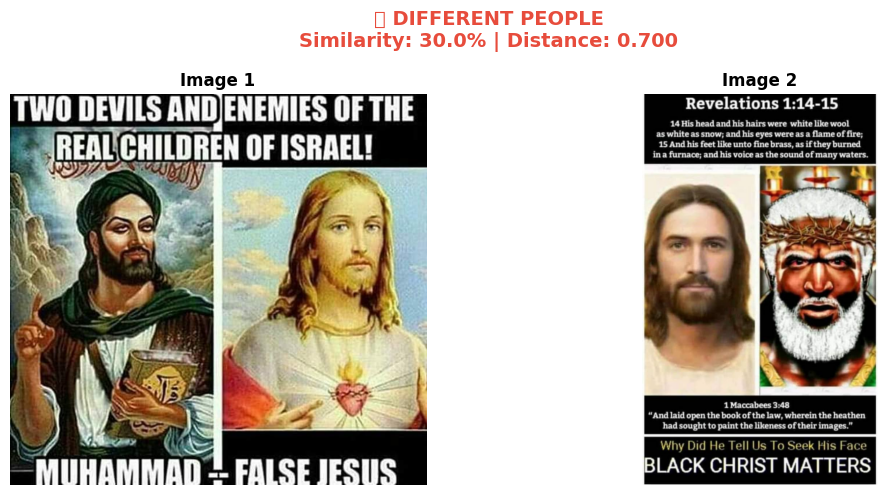

In [12]:
def compare_faces(image_path1, image_path2, tolerance=0.6):
    """Compare faces between two images."""
    _, fr_img1, _ = load_image(image_path1)
    _, fr_img2, _ = load_image(image_path2)

    locs1, encs1 = detect_faces(fr_img1)
    locs2, encs2 = detect_faces(fr_img2)

    print(f'Image 1: {len(locs1)} face(s) | Image 2: {len(locs2)} face(s)')

    if not encs1 or not encs2:
        print('❌ Could not detect faces in one or both images.')
        return

    match   = face_recognition.compare_faces([encs1[0]], encs2[0], tolerance=tolerance)[0]
    distance= face_recognition.face_distance([encs1[0]], encs2[0])[0]
    similarity = (1 - distance) * 100

    # Display side by side
    pil1 = Image.open(image_path1).convert('RGB')
    pil2 = Image.open(image_path2).convert('RGB')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(pil1); axes[0].set_title('Image 1', fontweight='bold'); axes[0].axis('off')
    axes[1].imshow(pil2); axes[1].set_title('Image 2', fontweight='bold'); axes[1].axis('off')

    result_color = '#2ECC71' if match else '#E74C3C'
    result_text  = '✅ SAME PERSON' if match else '❌ DIFFERENT PEOPLE'
    fig.suptitle(f'{result_text}\nSimilarity: {similarity:.1f}% | Distance: {distance:.3f}',
                 fontsize=14, fontweight='bold', color=result_color)
    plt.tight_layout()
    plt.savefig('face_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Upload TWO images to compare faces:')
uploaded2 = files.upload()

if len(uploaded2) >= 2:
    imgs = list(uploaded2.keys())
    compare_faces(imgs[0], imgs[1])
elif len(uploaded2) == 1:
    print('Please upload 2 images for comparison. Re-run this cell and upload 2 files.')


## **Face Recognition with Webcam**

In [13]:
# WEBCAM DETECTION — Run this script locally (not on Colab)
# Save as webcam_detection.py and run with: python webcam_detection.py

webcam_code = '''
import cv2
import face_recognition
import numpy as np

def run_webcam_detection():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return

    print("Webcam started. Press Q to quit.")
    frame_count  = 0
    process_every = 3  # Process every 3rd frame for speed

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1
        display_frame = frame.copy()

        if frame_count % process_every == 0:
            small_frame = cv2.resize(frame, (0, 0), fx=0.5, fy=0.5)
            rgb_small   = cv2.cvtColor(small_frame, cv2.COLOR_BGR2RGB)
            face_locs   = face_recognition.face_locations(rgb_small)

            for (top, right, bottom, left) in face_locs:
                top    *= 2; right *= 2; bottom *= 2; left *= 2
                cv2.rectangle(display_frame, (left, top), (right, bottom), (0, 255, 0), 3)
                cv2.rectangle(display_frame, (left, bottom - 35), (right, bottom), (0, 255, 0), cv2.FILLED)
                cv2.putText(display_frame, f"Face Detected",
                            (left + 6, bottom - 6), cv2.FONT_HERSHEY_DUPLEX, 0.8, (0, 0, 0), 1)

            face_count_text = f"Faces: {len(face_locs)}"
            cv2.putText(display_frame, face_count_text, (10, 30),
                        cv2.FONT_HERSHEY_DUPLEX, 1.0, (0, 255, 0), 2)

        cv2.imshow("Face Detection — Press Q to quit", display_frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Webcam closed.")

if __name__ == "__main__":
    run_webcam_detection()
'''

# Save the webcam script
with open('webcam_detection.py', 'w') as f:
    f.write(webcam_code)

print('webcam_detection.py saved!')
print('To run locally: python webcam_detection.py')


webcam_detection.py saved!
To run locally: python webcam_detection.py


## **Summary**

In [16]:
import os

print('     FACE RECOGNITION SYSTEM — SUMMARY')

outputs = ['annotated_output.png', 'face_crops.png',
           'face_comparison.png', 'webcam_detection.py']

print('\nGenerated Files:')
for f in outputs:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f'  {f} ({size/1024:.1f} KB)')
    else:
        print(f'  ⚪ {f} (not generated yet)')

print('\n Libraries Used:')
libs = [('OpenCV',           cv2.__version__),
        ('face_recognition', face_recognition.__version__),
        ('NumPy',            np.__version__),
        ('Pillow',           Image.__version__),
        ('Matplotlib',       plt.matplotlib.__version__)]
for name, ver in libs:
    print(f'  • {name:<20} v{ver}')

print('\nPipeline Complete!')
print('\nCapabilities Built:')
print('  • Single image face detection with bounding boxes')
print('  • Multi-face analysis with individual face crops')
print('  • Face similarity comparison between two images')
print('  • Real-time webcam detection script (local deployment)')

     FACE RECOGNITION SYSTEM — SUMMARY

Generated Files:
  annotated_output.png (1338.0 KB)
  face_crops.png (654.5 KB)
  face_comparison.png (932.8 KB)
  webcam_detection.py (1.6 KB)

 Libraries Used:
  • OpenCV               v4.13.0
  • face_recognition     v1.2.3
  • NumPy                v2.0.2
  • Pillow               v11.3.0
  • Matplotlib           v3.10.0

Pipeline Complete!

Capabilities Built:
  • Single image face detection with bounding boxes
  • Multi-face analysis with individual face crops
  • Face similarity comparison between two images
  • Real-time webcam detection script (local deployment)


In [17]:
import shutil
import os

# Create a zip of all output files
files_to_zip = []
for f in ['annotated_output.png', 'face_crops.png',
          'face_comparison.png', 'webcam_detection.py']:
    if os.path.exists(f):
        files_to_zip.append(f)

print('Files ready to download:')
for f in files_to_zip:
    print(f'  ✅ {f}')

Files ready to download:
  ✅ annotated_output.png
  ✅ face_crops.png
  ✅ face_comparison.png
  ✅ webcam_detection.py


In [18]:
from google.colab import files

for f in ['annotated_output.png', 'face_crops.png',
          'face_comparison.png', 'webcam_detection.py']:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>